## Phase 1: Advanced Descriptive Profiling
### 1. Pareto Analysis (80/20 Rule)
Do 20% of hackathons account for 80% of total participants?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

# Visual Configurations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
warnings.filterwarnings("ignore")

# Load and prep dataset
df = pd.read_csv("data/hackathon_multi_platform_dataset_v2.csv", low_memory=False)

# Clean dates and numerics
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
df['end_date'] = pd.to_datetime(df['end_date'], errors='coerce')
df['duration_days'] = (df['end_date'] - df['start_date']).dt.days
df['duration_days'] = df['duration_days'].apply(lambda x: x if pd.notnull(x) and 0 <= x <= 365 else np.nan)
df['participant_count'] = pd.to_numeric(df['participant_count'], errors='coerce').fillna(0)
df['prize_amount_numeric'] = pd.to_numeric(df['prize_amount_numeric'], errors='coerce').fillna(0)
df['year'] = df['start_date'].dt.year

# Participant concentration
df_sorted = df.sort_values('participant_count', ascending=False).reset_index(drop=True)
df_sorted['cumsum_pct'] = df_sorted['participant_count'].cumsum() / df_sorted['participant_count'].sum() * 100
df_sorted['rank_pct'] = (df_sorted.index + 1) / len(df_sorted) * 100

pareto_point = df_sorted[df_sorted['cumsum_pct'] <= 80]['rank_pct'].max()
print(f"Top {pareto_point:.1f}% of hackathons capture 80% of all participants.")

Top 17.7% of hackathons capture 80% of all participants.


### 2. Gini Coefficient for Prize Inequality
How unequally distributed are prize pools? Is the ecosystem winner-take-all?

In [2]:
def gini_coefficient(x):
    x = np.array(x, dtype=np.float64)
    x = x[~np.isnan(x) & (x > 0)]
    x = np.sort(x)
    n = len(x)
    cumsum = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cumsum) / cumsum[-1]) / n

for platform in ['devpost', 'unstop']:
    prizes = df[(df['platform'] == platform) & (df['prize_amount_numeric'] > 0)]['prize_amount_numeric']
    print(f"{platform.capitalize()}: Gini = {gini_coefficient(prizes):.3f}")

Devpost: Gini = 0.873
Unstop: Gini = 0.804


### 3. Cohort Analysis by Year
Did the characteristics of hackathons change as the market grew?

In [3]:
cohort = df.groupby('year').agg({
    'participant_count': 'median',
    'prize_amount_numeric': 'median',
    'duration_days': 'median',
    'has_cash_prize': 'mean',
    'is_online': 'mean'
}).round(2)
display(cohort.tail(10))

,participant_count,prize_amount_numeric,duration_days,has_cash_prize,is_online
year,,,,,
2017.0,30.0,350.00,0.0,1.00,0.06
2018.0,25.0,1050.00,0.0,1.00,0.06
2019.0,30.0,755.00,0.0,1.00,0.02
2020.0,40.0,500.00,0.0,1.00,0.41
2021.0,25.5,397.50,0.0,1.00,0.73
2022.0,241.0,180.72,0.0,0.81,0.64
2023.0,141.0,84.34,0.0,0.68,0.49
2024.0,194.5,120.48,0.0,0.71,0.47
2025.0,200.0,108.43,0.0,0.61,0.40


## Phase 2: Complete Associative & Correlation Framework
### 4. Correlation Matrix (Spearman, Point-Biserial, Cramer V)
Measuring relationships between mixed data types.

In [4]:
from scipy.stats import spearmanr, pointbiserialr

# Spearman for continuous pairs
cont_vars = ['participant_count', 'prize_amount_numeric', 'duration_days']
corr_matrix = df[cont_vars].corr(method='spearman')
print("Spearman Correlation Matrix (Continuous):\n", corr_matrix.round(2), "\n")

# Point-biserial: prize vs participants
r_pb, p_pb = pointbiserialr(df['has_cash_prize'], df['participant_count'])
print(f"Point-Biserial (Cash Prize vs Participants): r = {r_pb:.3f}, p = {p_pb:.2e}")

# Cramer V for categorical associations
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

print(f"Cramer V (Platform vs Organizer Type): {cramers_v(df['platform'], df['organizer_type']):.3f}")

Spearman Correlation Matrix (Continuous):
                       participant_count  prize_amount_numeric  duration_days
participant_count                  1.00                  0.19           0.20
prize_amount_numeric               0.19                  1.00           0.06
duration_days                      0.20                  0.06           1.00 

Point-Biserial (Cash Prize vs Participants): r = 0.002, p = 7.37e-01
Cramer V (Platform vs Organizer Type): 0.754


### 5. Cross-Tabulation with Normalization
What is the percentage breakdown of organizer types by platform?

In [5]:
ct = pd.crosstab(df['organizer_type'], df['platform'], normalize='index') * 100
display(ct.round(1))

platform,devpost,unstop
organizer_type,,
community,94.7,5.3
corporate,93.8,6.2
educational,23.7,76.3
independent,92.6,7.4
mlh_official,100.0,0.0
startup,37.0,63.0
unknown,100.0,0.0


## Phase 3: Deep Statistical Inference
### 6. Kruskal-Wallis Test (Organizer Type vs. Participation)
Is there a statistically significant difference in participation across different organizer types?

### 7. Chi-Square Test of Independence (Platform vs. Cash Prize Presence)
Is the distribution of cash prize events independent of the platform (Devpost vs. Unstop)?

### 8. Cliff's Delta Effect Size (Cash vs. No-Cash Participation)
Does offering a cash prize actually guarantee more participants, or is the effect size practically negligible?

Kruskal-Wallis H-test (Organizer Type): H = 731.18, p = 8.90e-156

Chi-Square Test (Platform vs. Cash Prize): Chi2 = 1715.06, p = 0.00e+00


has_cash_prize,False,True
platform,,
devpost,1471,11827
unstop,2119,3681



Cliff's Delta (Cash vs. No-Cash Effect Size on Participation): 0.013


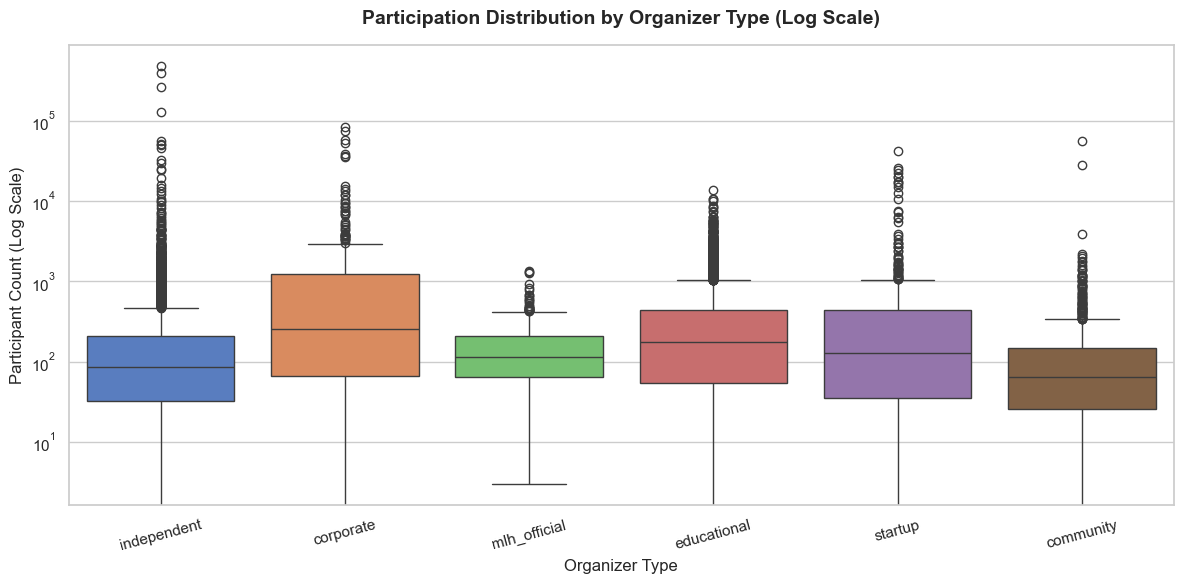

In [6]:
# Phase 3: Deep Statistical Inference
from scipy.stats import kruskal, chi2_contingency

# Kruskal-Wallis test across organizer types
org_df = df[df['organizer_type'] != 'unknown']
groups = [group['participant_count'].values for name, group in org_df.groupby('organizer_type')]
if len(groups) >= 2:
    h_stat, p_val = kruskal(*groups)
    print(f"Kruskal-Wallis H-test (Organizer Type): H = {h_stat:.2f}, p = {p_val:.2e}")

# Chi-Square test of Platform vs. Cash Prize Presence
contingency_table = pd.crosstab(df['platform'], df['has_cash_prize'])
chi2, p_chi, dof, ex = chi2_contingency(contingency_table)
print(f"\nChi-Square Test (Platform vs. Cash Prize): Chi2 = {chi2:.2f}, p = {p_chi:.2e}")
display(contingency_table)

# Cliff's Delta calculation
def cliffs_delta(x, y):
    x, y = np.array(x), np.array(y)
    xy = np.subtract.outer(x, y)
    return (np.sum(xy > 0) - np.sum(xy < 0)) / (len(x) * len(y))

with_cash = df[df['has_cash_prize'] == True]['participant_count']
without_cash = df[df['has_cash_prize'] == False]['participant_count']
delta = cliffs_delta(with_cash, without_cash)
print(f"\nCliff's Delta (Cash vs. No-Cash Effect Size on Participation): {delta:.3f}")

# Plotting boxplot comparing participation counts across organizer types
plt.figure(figsize=(12, 6))
sns.boxplot(data=org_df, x='organizer_type', y='participant_count', palette='muted')
plt.yscale('log')
plt.title('Participation Distribution by Organizer Type (Log Scale)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Organizer Type', fontsize=12)
plt.ylabel('Participant Count (Log Scale)', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('organizer_participation.png', dpi=300)
plt.show()

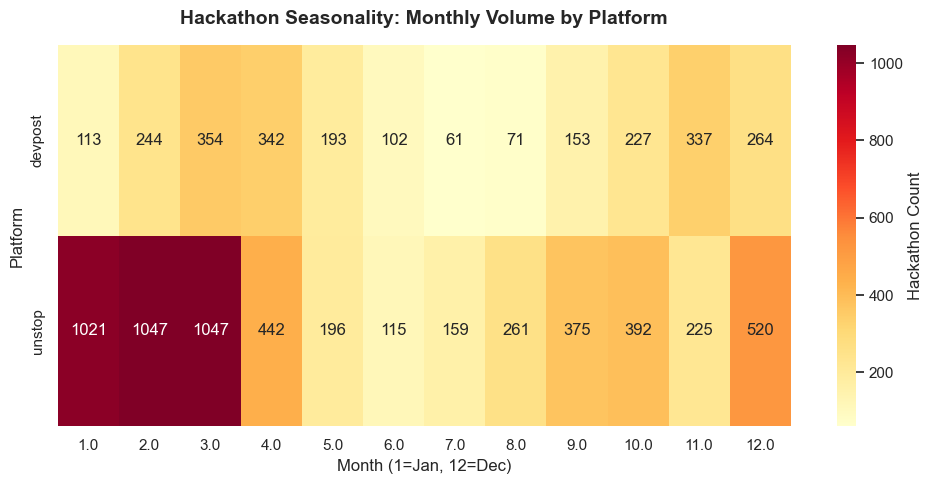

Hackathon Count Growth by Platform & Year:


platform,devpost,unstop
year,,
2005.0,0,1
2010.0,3,0
2011.0,1,0
2012.0,9,0
2013.0,20,0
2014.0,91,0
2015.0,114,0
2016.0,134,0
2017.0,175,0



Top 10 Themes in Hackathon Ecosystem:
theme
hackathon on d2c                                      506
["beginner friendly", "open ended", "social good"]    419
["beginner friendly", "open ended"]                   374
["beginner friendly"]                                 317
["machine learning/ai"]                               254
["beginner friendly", "education", "social good"]     222
["social good"]                                       217
["beginner friendly", "social good"]                  181
["beginner friendly", "education", "open ended"]      174
["open ended"]                                        167
Name: count, dtype: int64

Top 5 Theme Co-occurrences (Network Edges):
hackathon on d2c <--> hackathon on d2c: 95 events
hackathon on d2c <--> quiz on d2c: 78 events
quiz on d2c <--> quiz on d2c: 27 events


In [7]:
# Day 3 Analysis (Phases 4 & 5)
# Month-by-month Volume Seasonality Heatmap
df['month'] = df['start_date'].dt.month
seasonal = df.groupby(['month', 'platform']).size().unstack().fillna(0)

plt.figure(figsize=(10, 5))
sns.heatmap(seasonal.T, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Hackathon Count'})
plt.title('Hackathon Seasonality: Monthly Volume by Platform', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month (1=Jan, 12=Dec)', fontsize=12)
plt.ylabel('Platform', fontsize=12)
plt.tight_layout()
plt.savefig('seasonal_heatmap.png', dpi=300)
plt.show()

# Platform Cohort Growth Evolution Table
cohort_growth = df.groupby(['year', 'platform']).size().unstack().fillna(0).astype(int)
print("Hackathon Count Growth by Platform & Year:")
display(cohort_growth)

# Theme bias and frequency
themes_df = df.assign(theme=df['themes'].astype(str).str.split('|')).explode('theme')
themes_df['theme'] = themes_df['theme'].str.strip().str.lower()
themes_df = themes_df[~themes_df['theme'].isin(['nan', 'none', '[]', ''])]

print("\nTop 10 Themes in Hackathon Ecosystem:")
print(themes_df['theme'].value_counts().head(10))

# Top Theme Co-occurrence Network weights
from collections import Counter
cooc = Counter()
for themes in df['themes'].dropna().astype(str):
    t_list = [t.strip().lower() for t in themes.split('|') if t.strip().lower() not in ['nan', 'none', '[]', '']]
    for i in range(len(t_list)):
        for j in range(i+1, len(t_list)):
            pair = tuple(sorted([t_list[i], t_list[j]]))
            cooc[pair] += 1

print("\nTop 5 Theme Co-occurrences (Network Edges):")
for edge, weight in cooc.most_common(5):
    print(f"{edge[0]} <--> {edge[1]}: {weight} events")